In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
batch_size = 128
lr = 0.0002
z_dim = 100
epochs = 10   # keep small for demo, increase to 20+ for better results
image_size = 64

In [ ]:
# Transformations
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5], [0.5])  # scale RGB to [-1, 1]
])

# Use CIFAR-10 as a proxy dataset (tiny, quick to train)
dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset loaded: {len(dataset)} images")

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


Dataset loaded: 50000 images


In [ ]:
# Generator
# -------------------------
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
# Discriminator
# -------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1, 1)

Epoch [1/10] | D loss: 0.2371 | G loss: 1.4366
Epoch [2/10] | D loss: 0.1579 | G loss: 2.7525
Epoch [3/10] | D loss: 0.6131 | G loss: 6.5915
Epoch [4/10] | D loss: 0.1458 | G loss: 2.8707
Epoch [5/10] | D loss: 0.3707 | G loss: 0.9422


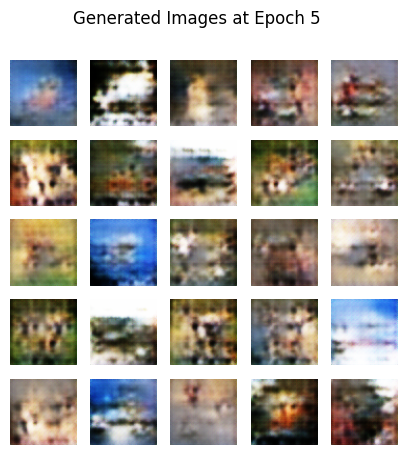

Epoch [6/10] | D loss: 0.0770 | G loss: 2.6136
Epoch [7/10] | D loss: 0.1665 | G loss: 4.1145
Epoch [8/10] | D loss: 0.1002 | G loss: 2.3325
Epoch [9/10] | D loss: 0.0409 | G loss: 3.0609
Epoch [10/10] | D loss: 0.0145 | G loss: 8.5905


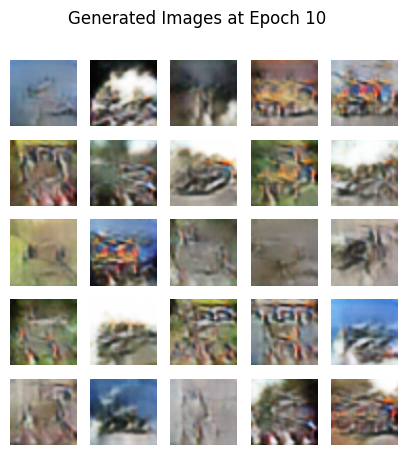

In [ ]:
# Initialize models, loss, optimizer
# -------------------------
generator = Generator(z_dim).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Fixed noise for monitoring
fixed_noise = torch.randn(25, z_dim, 1, 1, device=device)

# -------------------------
# Training Loop
# -------------------------
def save_generated_images(epoch, fixed_noise):
    with torch.no_grad():
        fake = generator(fixed_noise).detach().cpu()
    fake = (fake + 1) / 2  # rescale to [0,1]

    fig, axes = plt.subplots(5, 5, figsize=(5,5))
    for i, ax in enumerate(axes.flatten()):
        img = np.transpose(fake[i], (1,2,0))
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle(f"Generated Images at Epoch {epoch}")
    plt.show()

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        imgs = imgs.to(device)
        real = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), z_dim, 1, 1, device=device)
        gen_imgs = generator(z)
        g_loss = criterion(discriminator(gen_imgs), real)
        g_loss.backward()
        optimizer_G.step()

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(imgs), real)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    if (epoch+1) % 5 == 0:
        save_generated_images(epoch+1, fixed_noise)

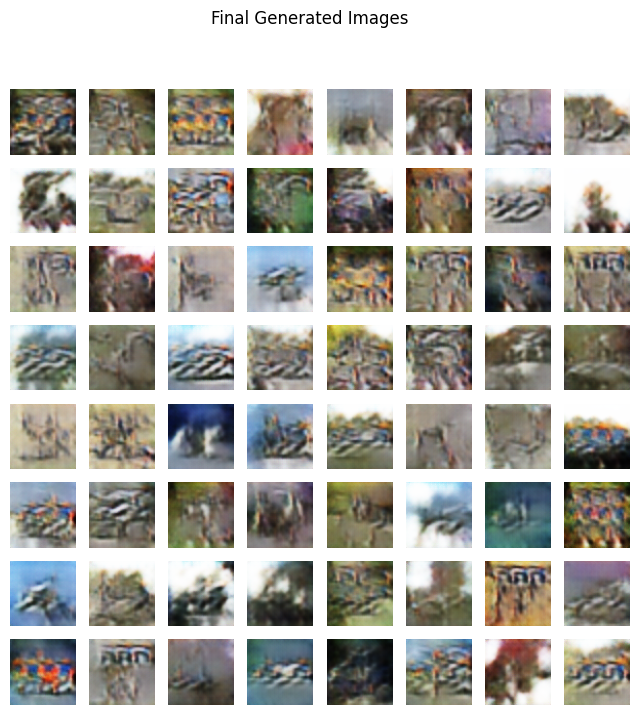

In [ ]:
with torch.no_grad():
    z = torch.randn(64, z_dim, 1, 1, device=device)
    gen_imgs = generator(z).detach().cpu()
gen_imgs = (gen_imgs + 1) / 2  # rescale to [0,1]

fig, axes = plt.subplots(8, 8, figsize=(8,8))
for i, ax in enumerate(axes.flatten()):
    img = np.transpose(gen_imgs[i], (1,2,0))
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Final Generated Images")
plt.show()


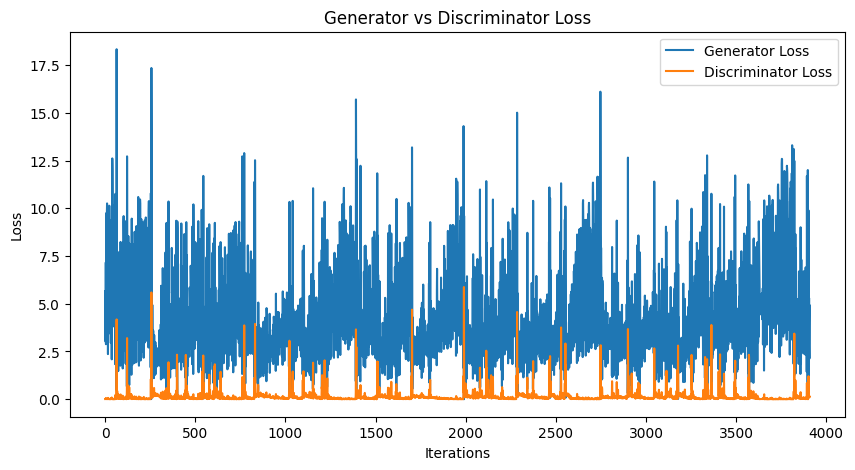

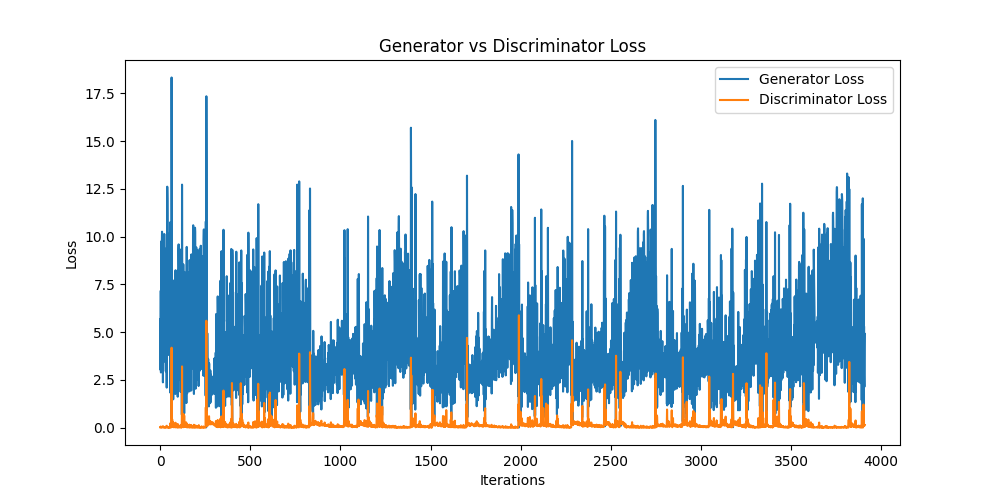

In [ ]:
G_losses = []
D_losses = []

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        imgs = imgs.to(device)
        real = torch.ones(imgs.size(0), 1, device=device)
        fake = torch.zeros(imgs.size(0), 1, device=device)

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), z_dim, 1, 1, device=device)
        gen_imgs = generator(z)
        g_loss = criterion(discriminator(gen_imgs), real)
        g_loss.backward()
        optimizer_G.step()

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(imgs), real)
        fake_loss = criterion(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # after each batch training
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())


# After training:
plt.figure(figsize=(10,5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.title("Generator vs Discriminator Loss")
plt.savefig("gan_loss_plot.png")  # Save the figure
plt.show()

from IPython.display import display, Image
display(Image("gan_loss_plot.png")) # Display the saved image